# Can we automatically test whether a random sample is approximately normally distributed?

In [1]:
%config InteractiveShell.ast_node_interactivity='last_expr_or_assign'  # always print last expr.
%config InlineBackend.figure_format = 'svg'
%load_ext autoreload
%autoreload 2
%matplotlib inline

import logging

logging.basicConfig(level=logging.INFO)

In [2]:
import matplotlib.pyplot as plt
import numpy as np

np.set_printoptions(precision=4, floatmode="fixed", suppress=True)
rng = np.random.default_rng()

Generator(PCG64) at 0x7FB3647729E0

In [3]:
import numpy as np
from numpy.random import Generator
from scipy.stats import kstest
from scipy.stats import norm as normal

normal.random_state = np.random.default_rng(1234)

for n in (10, 100, 1000, 10_000):
    x = normal.rvs(size=(n,))
    A = normal.rvs(size=(n, n)) / np.sqrt(n)
    y = A @ x
    x_test = kstest(x, normal.cdf)
    y_test = kstest(y, normal.cdf)
    print(n, x_test, y_test, sep="\n")

10
KstestResult(statistic=0.23040623468965887, pvalue=0.5864183032958603)
KstestResult(statistic=0.37965024079356813, pvalue=0.08356092646709246)
100
KstestResult(statistic=0.09856183275107017, pvalue=0.26773621006570997)
KstestResult(statistic=0.07188389776459508, pvalue=0.6528706947230108)
1000
KstestResult(statistic=0.02804102371057715, pvalue=0.4039232141915109)
KstestResult(statistic=0.046706468037920446, pvalue=0.02467055533520568)
10000
KstestResult(statistic=0.013889814900473252, pvalue=0.04180492534750835)
KstestResult(statistic=0.010544379819501376, pvalue=0.21463686958825334)


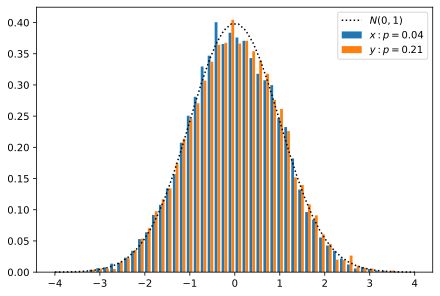

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(constrained_layout=True)
T = np.linspace(-4, 4)
ax.plot(T, normal.pdf(T), ":k")
ax.hist([x, y], bins=50, density=True)
ax.legend(["$N(0,1)$", f"$x: p={x_test.pvalue:.2f}$", f"$y: p={y_test.pvalue:.2f}$"])
fig.savefig("example.png")